# Day 3 — Bias-Variance & Diagnosing Model Fit

    Using the house prices dataset, we will be deliberately overfitting, underfitting then regularizing a Linear Regression model and examining the resulting scores and the gaps between the train/validation scores.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.tree import DecisionTreeRegressor

In [37]:
df = pd.read_csv("American_Housing_Data.csv")
df

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [38]:
df.dropna(inplace=True)

In [39]:
x = df.drop(["Price","Address","Zip Code","City","County"], axis = 1)
x = pd.get_dummies(x, drop_first=True)
y = df["Price"]

In [40]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    The dataset has been prepared and train/validation/test split. Next, we will be overfitting a Decision Tree model and observing the train/validation gap.

#### Overfitting

In [19]:
from sklearn.metrics import mean_squared_error

overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit.fit(X_train, y_train)

over_train_pred = overfit.predict(X_train)
over_val_pred = overfit.predict(X_val)


print("Overfit - Train [R²]:",overfit.score(X_train, y_train))
print("Overfit - Validation[R²]:",overfit.score(X_val, y_val))

Overfit - Train [R²]: 0.9998001298822783
Overfit - Validation[R²]: 0.4729771656754056


    The above results are the have shown a huge gap between the proportions of variance for the Training VS Validation data. This gap is due to the model memorizing data while training. As a result, the Validation predictions were very low in comparison to the Training predictions.

#### Underfitting

In [41]:
underfit = DecisionTreeRegressor(max_depth=1, random_state=42)
underfit.fit(X_train, y_train)

over_train_pred = underfit.predict(X_train)
over_val_pred = underfit.predict(X_val)

print("Underfit - Train [R²]:",underfit.score(X_train, y_train))
print("Underfit - Validation[R²]:",underfit.score(X_val, y_val))

Underfit - Train [R²]: 0.2058281176460548
Underfit - Validation[R²]: 0.23093199292402955


    The results for both training and testing are extremely low which indicates that the model is too simple to capture the patterns. The gap between the two is minimal which is an underfitting cause.

#### Regularization

In [42]:
depth = [1,2,3,5,7,10,15,20, None]
results = []

for d in depth:
    dtr =  DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr.fit(X_train, y_train)
    train = dtr.score(X_train, y_train)
    val = dtr.score(X_val, y_val)
    results.append((d, train, val))
    print(f"max_depth={d} | Train R² : {train:.4f}| Val R² : {val:.4f}")

    

max_depth=1 | Train R² : 0.2058| Val R² : 0.2309
max_depth=2 | Train R² : 0.3375| Val R² : 0.3339
max_depth=3 | Train R² : 0.4375| Val R² : 0.3734
max_depth=5 | Train R² : 0.7175| Val R² : 0.3532
max_depth=7 | Train R² : 0.8384| Val R² : 0.4588
max_depth=10 | Train R² : 0.9223| Val R² : 0.3739
max_depth=15 | Train R² : 0.9804| Val R² : 0.3448
max_depth=20 | Train R² : 0.9962| Val R² : 0.4155
max_depth=None | Train R² : 0.9998| Val R² : 0.4730


    The above data shows the bias-variance tradeoff and how it peaks at some areas and drops at others. For training data, it keeps growing until it almost reaches 1.0, while it grows, fluctuates, and peaks at the end for Validation. For better visualizing the results observe the following plot.

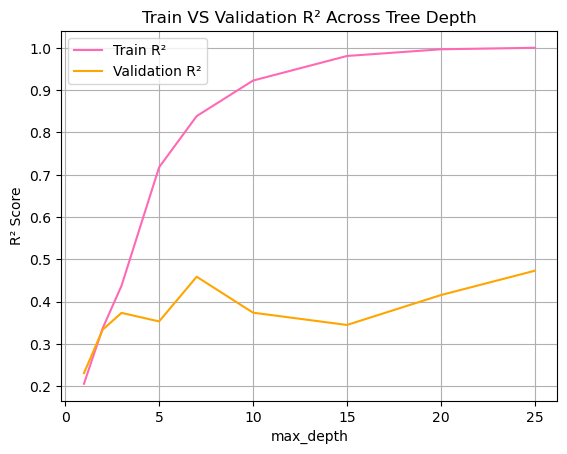

In [32]:
depths = [d if d is not None else 25 for d in depth]
train_score=[r[1] for r in results]
val_score = [r[2] for r in results]

plt.plot(depths, train_score, label="Train R²", color="hotpink")
plt.plot(depths, val_score, label="Validation R²", color="orange")
plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Train VS Validation R² Across Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

    The plot captures the gap between the two lines which is small at smaller depths(underfitting) and countinues to sharply widen as depth increases(overfittng). The selected value for Regularizing the model will be 7 as it provides the most reasonable test/validation gap.

In [35]:
reg = DecisionTreeRegressor(max_depth=7, random_state=42)
reg.fit(X_train,y_train)

print("Regularized - Train [R²]:", reg.score(X_train, y_train))
print("Regularized - Validation[R²]:", reg.score(X_val, y_val))

Regularized - Train [R²]: 0.8383801745425188
Regularized - Validation[R²]: 0.45877240673722774


    `Overfit`    | max_depth = None | ~0.53 gap
    `Underfit`   | max_depth = 1    | ~0.02 gap
    `Regularized`| max_depth = 7    | ~0.38 gap

    In conclusion, the model will typically show inconsistencies and prediction errors, but through regularization, the aim shifts towards finding thet most reliable best fit model.